# Tutorial 24 -- Sideband-Like Interactions

Use `SidebandDriveSpec` and `build_sideband_pulse(...)` to simulate an effective `|f,0> <-> |g,1>` exchange in a multilevel transmon-storage model.

**Prerequisites.** Tutorials 18 and 21 are recommended first.

**Scope note.** This notebook uses the repository's effective sideband-drive interface rather than a microscopic coupler model.


## 1. Goal

We will drive an effective red sideband and watch population transfer between `|f,0>` and `|g,1>`.


## 2. Physical Background

The structured `SidebandDriveSpec` API lets the runtime know which transmon transition and which bosonic mode participate in the effective sideband interaction. That is the stable public entry point for notebook-scale sideband studies.


## 3. Imports


In [1]:

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from cqed_sim import (
    DispersiveTransmonCavityModel,
    FrameSpec,
    Pulse,
    SequenceCompiler,
    SidebandDriveSpec,
    SimulationConfig,
    build_sideband_pulse,
    carrier_for_transition_frequency,
    sideband_transition_frequency,
    simulate_sequence,
)
from tutorials.tutorial_support import (
    GHz,
    MHz,
    ns,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (7.0, 4.2)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 4. Simulation Parameters


In [2]:
g_sb = 2.0 * np.pi * 8.0e6


## 5. Model Construction


In [3]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.0),
    omega_q=GHz(6.2),
    alpha=MHz(-220.0),
    chi=MHz(-0.8),
    kerr=0.0,
    n_cav=4,
    n_tr=3,
)
frame = FrameSpec(omega_c_frame=model.omega_c, omega_q_frame=model.omega_q)
target = SidebandDriveSpec(mode="storage", lower_level=0, upper_level=2, sideband="red")
omega_sb = sideband_transition_frequency(model, cavity_level=0, lower_level=0, upper_level=2, frame=frame)
t_swap = np.pi / (2.0 * g_sb)


## 6. Pulse / Sequence Construction


In [4]:
pulses, drive_ops, meta = build_sideband_pulse(
    target,
    duration_s=t_swap,
    amplitude_rad_s=g_sb,
    channel="sb",
    carrier=carrier_for_transition_frequency(omega_sb),
    label="gf_red_sideband",
)
compiled = SequenceCompiler(dt=t_swap / 400.0).compile(pulses, t_end=t_swap)


## 7. Running the Simulation


In [5]:
result = simulate_sequence(
    model,
    compiled,
    model.basis_state(2, 0),
    drive_ops,
    config=SimulationConfig(frame=frame, store_states=True, max_step=t_swap / 400.0),
)
target_state = model.basis_state(0, 1)
source_state = model.basis_state(2, 0)
p_g1 = np.array([abs(target_state.overlap(state)) ** 2 for state in result.states], dtype=float)
p_f0 = np.array([abs(source_state.overlap(state)) ** 2 for state in result.states], dtype=float)
print(f"Maximum transfer to |g,1> = {np.max(p_g1):.4f}")


Maximum transfer to |g,1> = 1.0000


## 8. Visualizing the Results


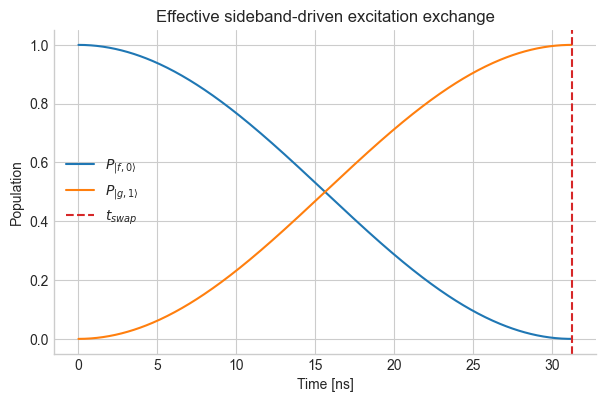

In [6]:
fig, ax = plt.subplots()
ax.plot(compiled.tlist / ns, p_f0, label=r"$P_{|f,0\rangle}$")
ax.plot(compiled.tlist / ns, p_g1, label=r"$P_{|g,1\rangle}$")
ax.axvline(t_swap / ns, color="tab:red", linestyle="--", label=r"$t_{swap}$")
ax.set_xlabel("Time [ns]")
ax.set_ylabel("Population")
ax.set_title("Effective sideband-driven excitation exchange")
ax.legend()
plt.show()


## 9. Physical Interpretation

The sideband drive does not look like a simple qubit-only rotation or a simple cavity displacement. Instead it moves amplitude between a multilevel transmon state and a bosonic Fock state according to the structured drive target.


## 10. Exercises / Next Steps

- Change `lower_level` and `upper_level` in the `SidebandDriveSpec` and see how the addressed transition changes.
- Add noise to study how open-system effects degrade the swap.
- Continue to Tutorial 26 for common bookkeeping mistakes around frames and carriers.
